# PatchTST — Subject-Dependent Within-Subject, Strict Leakage-Safe EMG + ACC
## Regularized paper version

**NinaPro DB7 | S01–S22 | gestures 13–29 | raw EMG + ACC | one fresh PatchTST per subject**

This version keeps the exact leakage-safe 4/1/1 repetition protocol, but reduces
PatchTST capacity and strengthens regularization because the original version had
about 2.0M parameters for only about 2k training windows per subject and could
reach 100% training accuracy very quickly.

Important: high validation accuracy is not automatically leakage in this protocol.
Train, validation, and test use different complete repetitions from the same person.
The purpose of these changes is to reduce memorization/overfitting while keeping the
evaluation protocol identical to the other subject-dependent models.

Protocol retained:

- one fresh model per subject
- deterministic 4 train / 1 validation / 1 test complete repetitions per gesture
- repetition split BEFORE filtering, ACC resampling, trimming, and windowing
- repetition-local zero-phase EMG filtering
- repetition-local ACC interval mapping + resampling
- 100 ms trim from both repetition boundaries
- 400 ms windows / 100 ms step
- train-only normalization for model selection
- validation selects epoch
- fresh train+validation normalizer + fresh model for final refit
- test repetition untouched until final evaluation

Regularized PatchTST:

- patch length = 100 samples
- patch stride = 50 samples
- d_model = 64
- 4 attention heads
- 2 Transformer encoder layers
- FFN = 128
- classifier hidden = 128
- dropout = 0.30
- AdamW weight decay = 1e-3
- label smoothing = 0.05
- gradient clipping = 1.0

This remains a **channel-independent PatchTST-style classifier**:
each EMG/ACC channel is patched and temporally encoded by the same shared
Transformer; channel embeddings are concatenated only in the classification head.

In [1]:
import os, gc, time, json, warnings, random, re, shutil
from pathlib import Path
from copy import deepcopy
from math import gcd

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import (
    resample_poly, butter, sosfiltfilt, iirnotch, filtfilt
)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Configuration — matched to the leakage-safe DNN/GNN within-subject protocol


In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    result = _search(child, depth + 1)
                    if result is not None:
                        return result
        except PermissionError:
            pass
        return None

    result = _search(base)
    return result if result else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    KAGGLE_INPUT = _find_kaggle_input()
    KAGGLE_WORKING = (
        Path('/kaggle/working')
        if Path('/kaggle').exists()
        else Path.cwd() / 'patchtst_within_working'
    )

    RUN_TAG = 'v2_patchtst_subject_dependent_regularized_r4v1t1_emg_acc'
    CKPT_DIR = KAGGLE_WORKING / f'ckpts_{RUN_TAG}'
    PLOT_DIR = KAGGLE_WORKING / f'plots_{RUN_TAG}'
    RESULTS_DIR = KAGGLE_WORKING / f'results_{RUN_TAG}'

    # Population
    INTACT_SUBJECTS = list(range(1, 21))
    AMPUTEE_SUBJECTS = [21, 22]
    SUBJECTS = list(range(1, 23))
    RUN_SUBJECTS = SUBJECTS.copy()  # use [1, 2] for a quick Kaggle smoke test
    PLOT_EACH_SUBJECT = False

    # True within-subject repetition split
    REPS_PER_GESTURE = 6
    TRAIN_REPS = 4
    VAL_REPS = 1
    TEST_REPS = 1

    # Labels 13..29 span E1 and E2
    EXERCISE_IDS = (1, 2)
    GESTURE_MIN = 13
    GESTURE_MAX = 29
    N_CLASSES = GESTURE_MAX - GESTURE_MIN + 1

    # Signal
    EMG_FS = 2000
    ACC_FS = 148
    TARGET_FS = 2000
    EMG_KEY = 'emg'
    ACC_KEY = 'acc'
    LBL_KEY = 'restimulus'
    N_EMG_CH = 12

    # EMG + ACC multimodal experiment.
    # ACC is segmented and resampled independently inside each complete repetition.
    USE_ACC = True

    # Fixed signal preprocessing; no statistics are learned from test data.
    BANDPASS_LOW_HZ = 20.0
    BANDPASS_HIGH_HZ = 450.0
    FILTER_ORDER = 4
    NOTCH_HZ = 50.0
    NOTCH_Q = 30.0

    # Same windowing as corrected DNN/GNN
    WIN_MS = 400
    STEP_MS = 100
    TRIM_MS = 100
    WIN_SAMPLES = int(WIN_MS * TARGET_FS / 1000)
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)
    TRIM_SAMPLES = int(TRIM_MS * TARGET_FS / 1000)

    # PatchTST classifier
    PATCH_LEN = 100
    PATCH_STRIDE = 50
    D_MODEL = 64
    N_HEADS = 4
    N_LAYERS = 2
    D_FF = 128
    DROPOUT = 0.30
    HEAD_HIDDEN = 128

    # Optimization
    MIN_EPOCHS = 10
    MAX_EPOCHS = 100
    PATIENCE = 10
    MIN_REFIT_EPOCHS = 10
    BATCH_SIZE = 32
    LR = 3e-4
    WEIGHT_DECAY = 1e-3
    LABEL_SMOOTHING = 0.05
    GRAD_CLIP = 1.0
    NUM_WORKERS = 0  # safer for large in-memory subject arrays on Kaggle
    REFIT_ON_TRAIN_PLUS_VAL = True
    KEEP_SUBJECT_CHECKPOINTS = False
    CLEAN_LEGACY_V4_CACHES = True

    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for directory in [
    Config.CKPT_DIR,
    Config.PLOT_DIR,
    Config.RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


def _clean_known_legacy_v4_caches():
    """Delete only large caches created by the earlier v4 MKA-CNN notebook."""
    if not Config.CLEAN_LEGACY_V4_CACHES:
        return

    legacy_names = [
        'raw_continuous_cache_v4_mka_cnn_emg_acc_subject_specific_r4v1t1_strict',
        'repetition_filtered_window_cache_v4_mka_cnn_emg_acc_subject_specific_r4v1t1_strict',
    ]

    for name in legacy_names:
        path = Config.KAGGLE_WORKING / name
        if path.exists() and path.is_dir():
            shutil.rmtree(path, ignore_errors=True)
            print(f'Removed old generated cache: {path.name}')


_clean_known_legacy_v4_caches()

assert Config.TRAIN_REPS + Config.VAL_REPS + Config.TEST_REPS == Config.REPS_PER_GESTURE
assert Config.USE_ACC is True
assert Config.PATCH_LEN <= Config.WIN_SAMPLES
assert Config.PATCH_STRIDE > 0
assert Config.D_MODEL % Config.N_HEADS == 0

print(f'Device             : {Config.DEVICE}')
print(f'Population         : {Config.SUBJECTS}')
print(f'Subject models     : {Config.RUN_SUBJECTS}')
print('Evaluation         : SUBJECT-DEPENDENT / SUBJECT-SPECIFIC WITHIN-SUBJECT')
print('Training rule      : train a fresh independent PatchTST separately for each subject')
print('Exercise files      : E1 + E2')
print(f'Input modality     : {"EMG + ACC" if Config.USE_ACC else "EMG only"}')
print('ACC handling       : repetition-local segment + repetition-local resampling')
print(f'Window / step      : {Config.WIN_MS} / {Config.STEP_MS} ms')
print(f'Boundary trim      : {Config.TRIM_MS} ms per repetition side')
print(f'Gestures           : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'Within split       : {Config.TRAIN_REPS} train + {Config.VAL_REPS} val + {Config.TEST_REPS} test repetitions')
print(f'Refit train+val    : {Config.REFIT_ON_TRAIN_PLUS_VAL}')
print(f'PatchTST           : patch={Config.PATCH_LEN}, stride={Config.PATCH_STRIDE}, d_model={Config.D_MODEL}, heads={Config.N_HEADS}, layers={Config.N_LAYERS}')
print(f'Regularization     : dropout={Config.DROPOUT}, weight_decay={Config.WEIGHT_DECAY}, label_smoothing={Config.LABEL_SMOOTHING}')
print('Persistent windows : disabled (disk-safe)')
print('Persistent raw cache: disabled (disk-safe)')

Device             : cuda
Population         : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Subject models     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Evaluation         : SUBJECT-DEPENDENT / SUBJECT-SPECIFIC WITHIN-SUBJECT
Training rule      : train a fresh independent PatchTST separately for each subject
Exercise files      : E1 + E2
Input modality     : EMG + ACC
ACC handling       : repetition-local segment + repetition-local resampling
Window / step      : 400 / 100 ms
Boundary trim      : 100 ms per repetition side
Gestures           : 13–29 (17 classes)
Within split       : 4 train + 1 val + 1 test repetitions
Refit train+val    : True
PatchTST           : patch=100, stride=50, d_model=64, heads=4, layers=2
Regularization     : dropout=0.3, weight_decay=0.001, label_smoothing=0.05
Persistent windows : disabled (disk-safe)
Persistent raw cache: disabled (disk-safe)


In [3]:
# Reproducibility and protocol assertions
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

assert Config.WIN_MS == 400
assert Config.STEP_MS == 100
assert Config.REPS_PER_GESTURE == 6
assert (Config.TRAIN_REPS, Config.VAL_REPS, Config.TEST_REPS) == (4, 1, 1)

print('Leakage-safe protocol configured.')
assert Config.PATCH_LEN == 100
assert Config.PATCH_STRIDE == 50


Leakage-safe protocol configured.


# Raw EMG + ACC loading — all signal transforms happen only AFTER repetition assignment


In [4]:
class RawEMGACCPreprocessor:
    """
    Load RAW EMG, RAW accelerometer and labels from one NinaPro file.

    No filtering, no ACC resampling, no label masking and no windowing happen here.
    Keeping each source file separate preserves the exact temporal mapping needed to
    extract a matching ACC interval for every EMG repetition.
    """

    @staticmethod
    def _find_key(data, candidates):
        for candidate in candidates:
            for key in data:
                if key.lower() == candidate.lower():
                    return key
        return None

    @staticmethod
    def _time_major(array, expected_channels=None, name='signal'):
        array = np.asarray(array)

        if array.ndim == 1:
            array = array[:, None]
        if array.ndim != 2:
            raise RuntimeError(
                f'{name}: expected 2-D array, got shape {array.shape}.'
            )

        if expected_channels is not None:
            if array.shape[1] == expected_channels:
                return array
            if array.shape[0] == expected_channels:
                return array.T
            raise RuntimeError(
                f'{name}: neither dimension matches expected '
                f'{expected_channels} channels: {array.shape}.'
            )

        # For ACC the time dimension should be much larger than channel count.
        if array.shape[0] < array.shape[1] and array.shape[0] <= 128:
            array = array.T

        return array

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY])
        lbl_key = self._find_key(
            data,
            [Config.LBL_KEY, 'stimulus', 'label', 'labels'],
        )

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if acc_key is None:
            raise KeyError(
                f'No ACC key in {mat_path.name}; EMG+ACC experiment requires accelerometer data.'
            )
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = self._time_major(
            data[emg_key],
            expected_channels=Config.N_EMG_CH,
            name=f'{mat_path.name} EMG',
        ).astype(np.float32)

        acc = self._time_major(
            data[acc_key],
            expected_channels=None,
            name=f'{mat_path.name} ACC',
        ).astype(np.float32)

        labels = np.asarray(
            data[lbl_key]
        ).reshape(-1).astype(np.int32)

        # restimulus is aligned with the EMG time base.
        n = min(len(emg), len(labels))
        emg = emg[:n]
        labels = labels[:n]

        if len(acc) < 2:
            raise RuntimeError(
                f'{mat_path.name}: ACC has only {len(acc)} samples.'
            )

        return emg, acc, labels


class RepetitionEMGFilter:
    """Zero-phase EMG filtering applied to one already-assigned repetition only."""

    def __init__(self):
        nyquist = Config.EMG_FS / 2.0
        self.sos = butter(
            Config.FILTER_ORDER,
            [
                Config.BANDPASS_LOW_HZ / nyquist,
                Config.BANDPASS_HIGH_HZ / nyquist,
            ],
            btype='bandpass',
            output='sos',
        )
        self.b_notch, self.a_notch = iirnotch(
            Config.NOTCH_HZ / nyquist,
            Config.NOTCH_Q,
        )

    def apply(self, repetition_emg):
        repetition_emg = np.asarray(
            repetition_emg,
            dtype=np.float32,
        )

        if repetition_emg.ndim != 2:
            raise ValueError(
                f'Expected (time,channels), got {repetition_emg.shape}.'
            )
        if len(repetition_emg) < 64:
            raise RuntimeError(
                f'EMG repetition unexpectedly short: {len(repetition_emg)} samples.'
            )

        filtered = sosfiltfilt(
            self.sos,
            repetition_emg,
            axis=0,
        )
        filtered = filtfilt(
            self.b_notch,
            self.a_notch,
            filtered,
            axis=0,
        )
        return filtered.astype(np.float32)


class RepetitionACCResampler:
    """
    Map an EMG repetition interval to the corresponding interval of the RAW ACC
    recording from the SAME source file, then resample only that ACC slice.

    This is leakage-safe because resample_poly never sees ACC samples belonging
    to another train/validation/test repetition.
    """

    @staticmethod
    def extract_matching_interval(
        file_acc: np.ndarray,
        file_emg_length: int,
        emg_start: int,
        emg_end: int,
    ) -> np.ndarray:
        if not (0 <= emg_start < emg_end <= file_emg_length):
            raise ValueError(
                f'Invalid EMG interval [{emg_start}, {emg_end}) '
                f'for file length {file_emg_length}.'
            )

        ratio = len(file_acc) / float(file_emg_length)

        # ceil(start) and ceil(end) keep selected ACC timestamps inside the
        # EMG repetition's temporal interval rather than borrowing a sample
        # from the preceding repetition/rest segment.
        acc_start = int(np.ceil(emg_start * ratio))
        acc_end = int(np.ceil(emg_end * ratio))

        acc_start = max(0, min(acc_start, len(file_acc) - 1))
        acc_end = max(acc_start + 1, min(acc_end, len(file_acc)))

        acc_rep = file_acc[acc_start:acc_end].copy()
        if len(acc_rep) < 2:
            raise RuntimeError(
                f'Mapped ACC repetition is too short: {len(acc_rep)} samples.'
            )

        return acc_rep

    @staticmethod
    def resample_to_emg_length(
        acc_rep: np.ndarray,
        target_length: int,
    ) -> np.ndarray:
        source_length = len(acc_rep)
        divisor = gcd(source_length, target_length)
        up = target_length // divisor
        down = source_length // divisor

        resampled = resample_poly(
            acc_rep,
            up,
            down,
            axis=0,
        ).astype(np.float32)

        # scipy normally gives the exact target length for this reduced ratio.
        # Handle any implementation-level one-sample discrepancy without using
        # data outside this repetition.
        if len(resampled) > target_length:
            resampled = resampled[:target_length]
        elif len(resampled) < target_length:
            pad_count = target_length - len(resampled)
            pad = np.repeat(
                resampled[-1:, :],
                pad_count,
                axis=0,
            )
            resampled = np.vstack([resampled, pad])

        if len(resampled) != target_length:
            raise RuntimeError(
                f'ACC resampling length mismatch: '
                f'{len(resampled)} != {target_length}.'
            )

        return resampled.astype(np.float32)


print('Raw EMG+ACC loader, repetition-local EMG filter and ACC resampler defined.')

Raw EMG+ACC loader, repetition-local EMG filter and ACC resampler defined.


# Subject loader — split complete repetitions first, then process EMG + ACC locally


In [5]:
class SubjectLoader:
    """
    Disk-safe subject loader.

    Only ONE subject is held in memory at a time. No raw signal cache and no
    overlapping-window cache is written to /kaggle/working.
    """

    def __init__(self):
        self.preprocessor = RawEMGACCPreprocessor()
        self.rep_filter = RepetitionEMGFilter()
        self.acc_resampler = RepetitionACCResampler()

    def _find_subject_dir(self, sid: int) -> Path:
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for path in candidates:
            if path.is_dir():
                return path

        for path in sorted(Config.KAGGLE_INPUT.iterdir()):
            if path.is_dir() and path.name.lower().endswith(str(sid)):
                return path

        raise FileNotFoundError(
            f'Cannot find subject {sid} under {Config.KAGGLE_INPUT}.'
        )

    @staticmethod
    def _is_exercise_file(path: Path, exercise_id: int) -> bool:
        name = path.stem.upper()
        return bool(
            re.search(rf'(^|_)E{exercise_id}(_|$)', name)
        )

    def _selected_files(self, sid: int):
        subject_dir = self._find_subject_dir(sid)
        all_mat_files = (
            sorted(subject_dir.glob('*.mat'))
            or sorted(subject_dir.rglob('*.mat'))
        )

        selected = []
        for exercise_id in Config.EXERCISE_IDS:
            matches = [
                path
                for path in all_mat_files
                if self._is_exercise_file(path, exercise_id)
            ]
            if not matches:
                raise FileNotFoundError(
                    f'S{sid:02d}: missing E{exercise_id}. '
                    f'Available: {[p.name for p in all_mat_files[:15]]}'
                )
            selected.extend(matches)

        return selected

    def _load_raw_parts_from_source(self, sid: int):
        """
        Read E1/E2 directly from the read-only Kaggle input and keep them only
        for the current subject.
        """
        parts = []
        acc_channel_counts = set()

        for index, mat_file in enumerate(self._selected_files(sid)):
            emg, acc, labels = self.preprocessor.apply(mat_file)

            if emg.shape[1] != Config.N_EMG_CH:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: expected '
                    f'{Config.N_EMG_CH} EMG channels, got {emg.shape[1]}.'
                )

            if acc.shape[1] <= 0:
                raise RuntimeError(
                    f'S{sid:02d}, {mat_file.name}: ACC is required.'
                )

            acc_channel_counts.add(int(acc.shape[1]))

            parts.append({
                'file_index': int(index),
                'file_name': mat_file.name,
                'emg': emg.astype(np.float32, copy=False),
                'acc': acc.astype(np.float32, copy=False),
                'labels': labels.astype(np.int32, copy=False),
            })

        if len(acc_channel_counts) != 1:
            raise RuntimeError(
                f'S{sid:02d}: inconsistent ACC channel counts across E1/E2: '
                f'{sorted(acc_channel_counts)}.'
            )

        return parts, int(next(iter(acc_channel_counts)))

    @staticmethod
    def _constant_label_runs(labels: np.ndarray):
        if len(labels) == 0:
            return

        boundaries = np.flatnonzero(
            np.diff(labels) != 0
        ) + 1
        starts = np.r_[0, boundaries]
        ends = np.r_[boundaries, len(labels)]

        for start, end in zip(starts, ends):
            yield (
                int(start),
                int(end),
                int(labels[start]),
            )

    @staticmethod
    def _repetition_id(sid, gesture, repetition_index):
        return (
            int(sid),
            int(gesture),
            int(repetition_index + 1),
        )

    @staticmethod
    def _split_repetition_indices(sid, gesture):
        rng = np.random.default_rng(
            Config.SEED
            + 1009 * int(sid)
            + 9176 * int(gesture)
        )
        perm = rng.permutation(
            Config.REPS_PER_GESTURE
        ).tolist()

        test_idx = sorted(
            perm[:Config.TEST_REPS]
        )
        val_idx = sorted(
            perm[
                Config.TEST_REPS:
                Config.TEST_REPS + Config.VAL_REPS
            ]
        )
        train_idx = sorted(
            perm[
                Config.TEST_REPS
                + Config.VAL_REPS:
            ]
        )

        if (
            len(train_idx) != Config.TRAIN_REPS
            or len(val_idx) != Config.VAL_REPS
            or len(test_idx) != Config.TEST_REPS
        ):
            raise RuntimeError('Unexpected repetition split size.')

        return train_idx, val_idx, test_idx

    def _collect_repetitions(self, parts):
        runs_by_gesture = {
            gesture: []
            for gesture in range(
                Config.GESTURE_MIN,
                Config.GESTURE_MAX + 1,
            )
        }

        for part_index, part in enumerate(parts):
            for (
                run_start,
                run_end,
                gesture,
            ) in self._constant_label_runs(part['labels']):
                if gesture in runs_by_gesture:
                    runs_by_gesture[gesture].append({
                        'part_index': int(part_index),
                        'start': int(run_start),
                        'end': int(run_end),
                    })

        return runs_by_gesture

    def build_subject_splits(
        self,
        sid: int,
        expected_n_acc_ch=None,
    ):
        """
        SUBJECT-DEPENDENT / WITHIN-SUBJECT leakage-safe ordering:

        one subject's raw E1/E2
          -> identify complete repetitions
          -> 4 train / 1 val / 1 test per gesture
          -> prove repetition IDs are disjoint
          -> filter each already-assigned EMG repetition locally
          -> extract and resample matching ACC interval locally
          -> concatenate EMG+ACC
          -> trim repetition boundaries
          -> create windows inside that repetition only

        Returned arrays live in RAM only and are deleted after this subject is
        trained/evaluated.
        """
        parts, n_acc_ch = self._load_raw_parts_from_source(sid)

        if (
            expected_n_acc_ch is not None
            and int(n_acc_ch) != int(expected_n_acc_ch)
        ):
            raise RuntimeError(
                f'S{sid:02d}: ACC channels={n_acc_ch}, '
                f'expected={expected_n_acc_ch}.'
            )

        runs_by_gesture = self._collect_repetitions(parts)

        split_X = {'train': [], 'val': [], 'test': []}
        split_y = {'train': [], 'val': [], 'test': []}
        split_rep_ids = {
            'train': set(),
            'val': set(),
            'test': set(),
        }
        assignment = {}

        expected_channels = Config.N_EMG_CH + n_acc_ch

        for gesture, runs in runs_by_gesture.items():
            if len(runs) != Config.REPS_PER_GESTURE:
                diagnostic = [
                    (
                        parts[record['part_index']]['file_name'],
                        record['start'],
                        record['end'],
                    )
                    for record in runs
                ]
                raise RuntimeError(
                    f'S{sid:02d}, gesture {gesture}: expected exactly '
                    f'{Config.REPS_PER_GESTURE} repetitions, found {len(runs)}. '
                    f'Runs={diagnostic}'
                )

            train_idx, val_idx, test_idx = (
                self._split_repetition_indices(
                    sid,
                    gesture,
                )
            )

            assignment[str(gesture)] = {
                'train_reps': [int(i + 1) for i in train_idx],
                'val_reps': [int(i + 1) for i in val_idx],
                'test_reps': [int(i + 1) for i in test_idx],
            }

            split_indices = {
                'train': train_idx,
                'val': val_idx,
                'test': test_idx,
            }
            class_id = gesture - Config.GESTURE_MIN

            # Register identities BEFORE filtering, resampling, or windowing.
            for split_name, rep_indices in split_indices.items():
                for rep_index in rep_indices:
                    split_rep_ids[split_name].add(
                        self._repetition_id(
                            sid,
                            gesture,
                            rep_index,
                        )
                    )

            assert split_rep_ids['train'].isdisjoint(
                split_rep_ids['val']
            )
            assert split_rep_ids['train'].isdisjoint(
                split_rep_ids['test']
            )
            assert split_rep_ids['val'].isdisjoint(
                split_rep_ids['test']
            )

            for split_name, rep_indices in split_indices.items():
                for rep_index in rep_indices:
                    record = runs[rep_index]
                    part = parts[record['part_index']]

                    run_start = record['start']
                    run_end = record['end']

                    # RAW EMG repetition.
                    emg_raw = part['emg'][
                        run_start:run_end
                    ].copy()

                    # Matching RAW ACC interval from the SAME source file.
                    acc_raw = (
                        self.acc_resampler.extract_matching_interval(
                            file_acc=part['acc'],
                            file_emg_length=len(part['emg']),
                            emg_start=run_start,
                            emg_end=run_end,
                        )
                    )

                    # Both operations see ONLY this already-assigned repetition.
                    emg_filtered = self.rep_filter.apply(
                        emg_raw
                    )
                    acc_resampled = (
                        self.acc_resampler.resample_to_emg_length(
                            acc_raw,
                            target_length=len(emg_filtered),
                        )
                    )

                    if acc_resampled.shape[1] != n_acc_ch:
                        raise RuntimeError(
                            f'S{sid:02d}, gesture {gesture}, rep '
                            f'{rep_index + 1}: ACC channel mismatch.'
                        )

                    repetition_signal = np.concatenate(
                        [
                            emg_filtered,
                            acc_resampled,
                        ],
                        axis=1,
                    ).astype(np.float32)

                    if repetition_signal.shape[1] != expected_channels:
                        raise RuntimeError(
                            f'S{sid:02d}: expected {expected_channels} '
                            f'combined channels, got '
                            f'{repetition_signal.shape[1]}.'
                        )

                    clean_start = Config.TRIM_SAMPLES
                    clean_end = (
                        len(repetition_signal)
                        - Config.TRIM_SAMPLES
                    )

                    if (
                        clean_end - clean_start
                        < Config.WIN_SAMPLES
                    ):
                        raise RuntimeError(
                            f'S{sid:02d}, gesture {gesture}, rep '
                            f'{rep_index + 1}: too short after trim.'
                        )

                    clean_rep = repetition_signal[
                        clean_start:clean_end
                    ]

                    for start in range(
                        0,
                        len(clean_rep)
                        - Config.WIN_SAMPLES
                        + 1,
                        Config.STEP_SAMPLES,
                    ):
                        window = clean_rep[
                            start:
                            start + Config.WIN_SAMPLES
                        ].T.copy()

                        split_X[split_name].append(window)
                        split_y[split_name].append(class_id)

                    del (
                        emg_raw,
                        acc_raw,
                        emg_filtered,
                        acc_resampled,
                        repetition_signal,
                        clean_rep,
                    )

        # Final repetition-level leakage proof.
        assert split_rep_ids['train'].isdisjoint(
            split_rep_ids['val']
        )
        assert split_rep_ids['train'].isdisjoint(
            split_rep_ids['test']
        )
        assert split_rep_ids['val'].isdisjoint(
            split_rep_ids['test']
        )

        expected_total_reps = (
            Config.N_CLASSES
            * Config.REPS_PER_GESTURE
        )
        all_rep_ids = (
            split_rep_ids['train']
            | split_rep_ids['val']
            | split_rep_ids['test']
        )

        if len(all_rep_ids) != expected_total_reps:
            raise RuntimeError(
                f'S{sid:02d}: expected {expected_total_reps} unique '
                f'repetition IDs, found {len(all_rep_ids)}.'
            )

        result = {}

        for split_name in ('train', 'val', 'test'):
            if not split_X[split_name]:
                raise RuntimeError(
                    f'S{sid:02d}: no {split_name} windows created.'
                )

            X = np.stack(
                split_X[split_name]
            ).astype(np.float32)
            y = np.asarray(
                split_y[split_name],
                dtype=np.int64,
            )

            if X.shape[1] != expected_channels:
                raise RuntimeError(
                    f'S{sid:02d}: {split_name} channel mismatch.'
                )

            present = set(np.unique(y).tolist())
            expected_classes = set(
                range(Config.N_CLASSES)
            )
            if present != expected_classes:
                missing = sorted(
                    expected_classes - present
                )
                raise RuntimeError(
                    f'S{sid:02d}: {split_name} missing '
                    f'class IDs {missing}.'
                )

            result[f'X_{split_name}'] = X
            result[f'y_{split_name}'] = y

        provenance = {
            split_name: [
                list(rep_id)
                for rep_id in sorted(
                    split_rep_ids[split_name]
                )
            ]
            for split_name in ('train', 'val', 'test')
        }

        print(
            f'  S{sid:02d}: RAM-only strict EMG+ACC windows | '
            f'train={result["X_train"].shape}, '
            f'val={result["X_val"].shape}, '
            f'test={result["X_test"].shape}'
        )
        print(
            f'    {expected_channels} channels '
            f'({Config.N_EMG_CH} EMG + {n_acc_ch} ACC) | '
            f'repetition IDs '
            f'{len(split_rep_ids["train"])}/'
            f'{len(split_rep_ids["val"])}/'
            f'{len(split_rep_ids["test"])} | disjoint'
        )

        del parts, split_X, split_y
        gc.collect()

        return result, assignment, provenance, n_acc_ch


print(
    'Disk-safe subject-dependent leakage-safe '
    'EMG+ACC SubjectLoader defined.'
)

Disk-safe subject-dependent leakage-safe EMG+ACC SubjectLoader defined.


# Training-only channel normalization


In [6]:
class ChannelNormalizer:
    """Per-channel mean/std. Fit only on the current subject's training pool."""

    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X: np.ndarray):
        if len(X) == 0:
            raise ValueError('Cannot fit ChannelNormalizer on an empty array.')
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std = X.std(axis=(0, 2), keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            raise RuntimeError('ChannelNormalizer must be fitted before transform().')
        return ((X - self.mean) / self.std).astype(np.float32)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


print('Training-only ChannelNormalizer defined.')

Training-only ChannelNormalizer defined.


# PyTorch dataset


In [7]:
class EMGWindowDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X.astype(np.float32, copy=False))
        self.y = torch.from_numpy(y.astype(np.int64, copy=False))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# PatchTST classifier

Key ideas retained:

- temporal patching of each raw EMG/ACC channel
- shared patch projection across channels
- shared Transformer encoder across channels
- self-attention over temporal patches
- classification head after pooling each channel's patch embeddings

In [8]:
class PatchTSTClassifier(nn.Module):
    """Channel-independent PatchTST-style classifier for raw EMG+ACC windows."""

    def __init__(
        self,
        n_channels: int,
        n_classes: int,
        patch_len: int = Config.PATCH_LEN,
        patch_stride: int = Config.PATCH_STRIDE,
        d_model: int = Config.D_MODEL,
        n_heads: int = Config.N_HEADS,
        n_layers: int = Config.N_LAYERS,
        d_ff: int = Config.D_FF,
        dropout: float = Config.DROPOUT,
        head_hidden: int = Config.HEAD_HIDDEN,
        win_samples: int = Config.WIN_SAMPLES,
    ):
        super().__init__()

        self.n_channels = int(n_channels)
        self.n_classes = int(n_classes)
        self.patch_len = int(patch_len)
        self.patch_stride = int(patch_stride)
        self.d_model = int(d_model)
        self.win_samples = int(win_samples)

        if self.patch_len > self.win_samples:
            raise ValueError('Patch length exceeds window length.')
        if self.patch_stride <= 0:
            raise ValueError('Patch stride must be positive.')
        if self.d_model % int(n_heads) != 0:
            raise ValueError('d_model must be divisible by n_heads.')

        self.n_patches = (
            1
            + (
                self.win_samples
                - self.patch_len
            )
            // self.patch_stride
        )

        self.patch_projection = nn.Linear(
            self.patch_len,
            self.d_model,
        )

        self.positional_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.n_patches,
                self.d_model,
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=int(n_heads),
            dim_feedforward=int(d_ff),
            dropout=float(dropout),
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=int(n_layers),
            norm=nn.LayerNorm(
                self.d_model
            ),
        )

        self.embedding_dropout = nn.Dropout(
            float(dropout)
        )

        self.head = nn.Sequential(
            nn.LayerNorm(
                self.n_channels
                * self.d_model
            ),
            nn.Linear(
                self.n_channels
                * self.d_model,
                int(head_hidden),
            ),
            nn.GELU(),
            nn.Dropout(
                float(dropout)
            ),
            nn.Linear(
                int(head_hidden),
                self.n_classes,
            ),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(
            self.positional_embedding,
            std=0.02,
        )

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(
                    module.weight
                )
                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def make_patches(self, x):
        if x.ndim != 3:
            raise ValueError(
                f'Expected (B,C,T), got {tuple(x.shape)}.'
            )

        if x.shape[1] != self.n_channels:
            raise ValueError(
                f'Expected {self.n_channels} channels, got {x.shape[1]}.'
            )

        if x.shape[2] != self.win_samples:
            raise ValueError(
                f'Expected {self.win_samples} samples, got {x.shape[2]}.'
            )

        patches = x.unfold(
            dimension=-1,
            size=self.patch_len,
            step=self.patch_stride,
        ).contiguous()

        if patches.shape[2] != self.n_patches:
            raise RuntimeError(
                f'Expected {self.n_patches} patches, got {patches.shape[2]}.'
            )

        return patches

    def encode_channels(self, x):
        patches = self.make_patches(
            x
        )

        B, C, P, L = patches.shape

        # Channel-independent processing:
        # fold channels into the batch and apply the SAME encoder to every channel.
        patches = patches.reshape(
            B * C,
            P,
            L,
        )

        tokens = self.patch_projection(
            patches
        )

        tokens = (
            tokens
            + self.positional_embedding[
                :,
                :P,
                :
            ]
        )

        tokens = self.embedding_dropout(
            tokens
        )

        encoded = self.encoder(
            tokens
        )

        # Temporal pooling inside each channel.
        channel_embedding = encoded.mean(
            dim=1
        )

        return channel_embedding.reshape(
            B,
            C,
            self.d_model,
        )

    def forward(self, x):
        channel_embedding = (
            self.encode_channels(
                x
            )
        )

        flattened = channel_embedding.reshape(
            channel_embedding.shape[0],
            self.n_channels
            * self.d_model,
        )

        return self.head(
            flattened
        )

    def count_params(self):
        return sum(
            p.numel()
            for p in self.parameters()
            if p.requires_grad
        )


_preview_model = PatchTSTClassifier(
    n_channels=48,
    n_classes=Config.N_CLASSES,
)

print('PatchTST classifier defined.')
print(f'Preview input            : (B, 48, {Config.WIN_SAMPLES})')
print(f'Patch length / stride    : {Config.PATCH_LEN} / {Config.PATCH_STRIDE}')
print(f'Patches/channel          : {_preview_model.n_patches}')
print(f'd_model / heads / layers : {Config.D_MODEL} / {Config.N_HEADS} / {Config.N_LAYERS}')
print(f'Preview parameters       : {_preview_model.count_params():,}')
del _preview_model

PatchTST classifier defined.
Preview input            : (B, 48, 800)
Patch length / stride    : 100 / 50
Patches/channel          : 15
d_model / heads / layers : 64 / 4 / 2
Preview parameters       : 476,177


### Architecture note

The old MKA-CNN class that was accidentally retained in the first PatchTST notebook has been removed. Only `PatchTSTClassifier` is used here.


# Optional GFLOPs estimate


In [9]:
def compute_gflops(
    model,
    n_channels,
    win_samples=Config.WIN_SAMPLES,
):
    if not HAS_THOP:
        return -1.0

    try:
        dummy = torch.zeros(
            1,
            n_channels,
            win_samples,
        )
        macs, _ = thop_profile(
            deepcopy(model).cpu(),
            inputs=(dummy,),
            verbose=False,
        )
        return float(
            macs * 2 / 1e9
        )
    except Exception:
        return -1.0

# Trainer — validation selects epoch; final model can be refitted on train+validation


In [10]:
class Trainer:
    def __init__(self, model, save_path: Path, n_classes: int):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.n_classes = n_classes
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }
        self.best_epoch = 0
        self.best_val_loss = float('inf')
        self.train_wall = 0.0

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)

        total_loss, correct, total = 0.0, 0, 0
        context = torch.enable_grad() if training else torch.no_grad()

        with context:
            for X, y in loader:
                X = X.to(Config.DEVICE, non_blocking=True)
                y = y.to(Config.DEVICE, non_blocking=True)

                logits = self.model(X)
                loss = criterion(logits, y)

                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        Config.GRAD_CLIP,
                    )
                    optimizer.step()

                total_loss += loss.item() * len(y)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)

        return total_loss / max(total, 1), correct / max(total, 1)

    def fit(self, train_loader, val_loader):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.WEIGHT_DECAY,
        )
        criterion = nn.CrossEntropyLoss(
            label_smoothing=Config.LABEL_SMOOTHING,
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=Config.MAX_EPOCHS,
        )

        patience_count = 0
        start_wall = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            tr_loss, tr_acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            vl_loss, vl_acc = self._run_epoch(
                val_loader, criterion=criterion
            )
            scheduler.step()

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            if vl_loss < self.best_val_loss:
                self.best_val_loss = float(vl_loss)
                self.best_epoch = int(epoch)
                patience_count = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_count += 1

            if epoch == 1 or epoch % 10 == 0:
                print(
                    f'  Epoch {epoch:3d} | '
                    f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | '
                    f'val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}'
                )

            if epoch >= Config.MIN_EPOCHS and patience_count >= Config.PATIENCE:
                print(
                    f'  Early stop at epoch {epoch} '
                    f'(patience={Config.PATIENCE})'
                )
                break

        self.train_wall = time.perf_counter() - start_wall
        best_idx = max(self.best_epoch - 1, 0)
        best_train_acc = float(self.history['train_acc'][best_idx])
        best_val_acc = float(self.history['val_acc'][best_idx])
        generalization_gap = best_train_acc - best_val_acc

        print(
            f'  Selection training: {self.train_wall:.1f} s | '
            f'best epoch={self.best_epoch} | '
            f'best val_loss={self.best_val_loss:.4f} | '
            f'gap={generalization_gap:.4f}'
        )

        if generalization_gap > 0.10:
            print(
                '  Warning: train-validation accuracy gap > 0.10; '
                'the subject-specific model is still overfitting.'
            )

        return self

    def fit_fixed_epochs(self, train_loader, epochs: int):
        """Fresh final model training on train+validation after epoch selection."""
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.WEIGHT_DECAY,
        )
        criterion = nn.CrossEntropyLoss(
            label_smoothing=Config.LABEL_SMOOTHING,
        )
        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=max(int(epochs), 1),
        )

        start_wall = time.perf_counter()
        for epoch in range(1, int(epochs) + 1):
            loss, acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or epoch == int(epochs):
                print(
                    f'  Refit epoch {epoch:3d}/{int(epochs)} | '
                    f'loss={loss:.4f} | acc={acc:.4f}'
                )

        self.train_wall = time.perf_counter() - start_wall
        torch.save(self.model.state_dict(), self.save_path)
        print(f'  Refit training: {self.train_wall:.1f} s')
        return self


print('Trainer defined.')

Trainer defined.


# Evaluator

In [11]:
class Evaluator:
    def __init__(self, model_cls, model_kwargs, save_path: Path, n_classes: int, class_names: list):
        self.model_cls = model_cls
        self.model_kwargs = model_kwargs
        self.save_path = save_path
        self.n_classes = n_classes
        self.class_names = class_names

    def _load_model(self):
        model = self.model_cls(**self.model_kwargs)
        model.load_state_dict(torch.load(self.save_path, map_location=Config.DEVICE))
        model.to(Config.DEVICE).eval()
        return model

    def evaluate(self, test_loader, split_tag: str) -> dict:
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(Config.DEVICE)
                logits = model(X)
                proba = torch.softmax(logits, dim=1).cpu().numpy()
                preds = logits.argmax(1).cpu().numpy()
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall
        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true = np.concatenate(all_true)
        n_test = len(all_true)

        acc_overall = accuracy_score(all_true, all_preds)
        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(accuracy_score(all_true[mask], all_preds[mask]))

        precision = precision_score(all_true, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_true, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)
        
        try:
            roc_auc = roc_auc_score(all_true, all_proba, multi_class='ovr', average='weighted', labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        gflops = compute_gflops(model, model.n_channels)

        metrics = {
            'split': split_tag,
            'accuracy': acc_overall,
            'precision_w': precision,
            'recall_w': recall,
            'f1_w': f1,
            'roc_auc_w': roc_auc,
            'per_class_acc': per_class_acc,
            'test_wall_s': test_wall,
            'test_samples': n_test,
            'gflops_per_window': gflops,
            'input_size': f"(1, {model.n_channels}, {Config.WIN_SAMPLES})",
        }

        tag = split_tag.replace(':', '_')
        if Config.PLOT_EACH_SUBJECT:
            self._plot_confusion(all_true, all_preds, split_tag, tag)
            self._plot_roc(all_true, all_proba, split_tag, tag)

        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm = confusion_matrix(y_true, y_pred, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, label in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names, annot=(self.n_classes <= 17), fmt='.2f' if label == 'Normalised' else 'd', linewidths=0.3)
            ax.set_title(f"Confusion Matrix ({label}) — {title}", fontsize=11)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0, labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2, label=f"{self.class_names[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {title}", fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')

# Learning-curve plotter


In [12]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss')
    axes[0].plot(epochs, history['val_loss'], label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'Learning Curve (Loss) — {split_tag}')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc')
    axes[1].plot(epochs, history['val_acc'], label='Val acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Learning Curve (Accuracy) — {split_tag}')
    axes[1].legend()

    plt.tight_layout()
    tag = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show() 
    plt.close('all')
    print(f"    Curves saved → {path.name}")

# Subject-dependent experiment — one fresh PatchTST per subject


In [13]:
class SubjectDependentPatchTSTExperiment:
    def __init__(
        self,
        sid: int,
        data: dict,
        n_channels: int,
        n_classes: int,
        class_names: list,
    ):
        self.sid = int(sid)
        self.data = data
        self.n_channels = int(n_channels)
        self.n_classes = int(n_classes)
        self.class_names = class_names

    @staticmethod
    def _loader(X, y, shuffle):
        return DataLoader(
            EMGWindowDataset(
                X,
                y,
            ),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(
                Config.DEVICE.type
                == 'cuda'
            ),
            persistent_workers=False,
        )

    def run(self):
        tag = (
            f'SUBJECT_DEPENDENT_PATCHTST_'
            f'S{self.sid:02d}_R4_V1_T1'
        )

        print('\n' + '=' * 70)
        print(
            f'  SUBJECT S{self.sid:02d} — '
            'SUBJECT-DEPENDENT within-subject PatchTST'
        )
        print('=' * 70)

        X_train_raw = self.data['X_train']
        y_train = self.data['y_train']
        X_val_raw = self.data['X_val']
        y_val = self.data['y_val']
        X_test_raw = self.data['X_test']
        y_test = self.data['y_test']

        print(
            f'  Windows | train={len(y_train):,} | '
            f'val={len(y_val):,} | test={len(y_test):,}'
        )

        # Sanity checks: these do not replace the repetition-ID proof in SubjectLoader.
        assert X_train_raw is not X_val_raw
        assert X_train_raw is not X_test_raw
        assert X_val_raw is not X_test_raw
        assert len(X_train_raw) > 0 and len(X_val_raw) > 0 and len(X_test_raw) > 0

        print(
            '  Split audit: complete train/val/test repetition sets were '
            'created independently before preprocessing/windowing.'
        )

        # ---------------- MODEL SELECTION: TRAIN only ----------------
        selection_normalizer = ChannelNormalizer()
        X_train = selection_normalizer.fit_transform(
            X_train_raw
        )
        X_val = selection_normalizer.transform(
            X_val_raw
        )

        train_loader = self._loader(
            X_train,
            y_train,
            shuffle=True,
        )
        val_loader = self._loader(
            X_val,
            y_val,
            shuffle=False,
        )

        model_kwargs = {
            'n_channels': self.n_channels,
            'n_classes': self.n_classes,
            'patch_len': Config.PATCH_LEN,
            'patch_stride': Config.PATCH_STRIDE,
            'd_model': Config.D_MODEL,
            'n_heads': Config.N_HEADS,
            'n_layers': Config.N_LAYERS,
            'd_ff': Config.D_FF,
            'dropout': Config.DROPOUT,
            'head_hidden': Config.HEAD_HIDDEN,
            'win_samples': Config.WIN_SAMPLES,
        }

        selection_model = PatchTSTClassifier(
            **model_kwargs
        )
        selection_path = (
            Config.CKPT_DIR
            / f'patchtst_{tag}_selection.pt'
        )

        selection_trainer = Trainer(
            selection_model,
            selection_path,
            self.n_classes,
        )
        selection_trainer.fit(
            train_loader,
            val_loader,
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_learning_curves(
                selection_trainer.history,
                tag,
            )

        # --------------- FINAL REFIT: TRAIN + VALIDATION only ---------------
        if Config.REFIT_ON_TRAIN_PLUS_VAL:
            X_refit_raw = np.concatenate(
                [
                    X_train_raw,
                    X_val_raw,
                ],
                axis=0,
            ).astype(
                np.float32
            )
            y_refit = np.concatenate(
                [
                    y_train,
                    y_val,
                ],
                axis=0,
            ).astype(
                np.int64
            )

            final_normalizer = ChannelNormalizer()
            X_refit = final_normalizer.fit_transform(
                X_refit_raw
            )
            X_test = final_normalizer.transform(
                X_test_raw
            )

            refit_loader = self._loader(
                X_refit,
                y_refit,
                shuffle=True,
            )
            test_loader = self._loader(
                X_test,
                y_test,
                shuffle=False,
            )

            refit_epochs = max(
                int(
                    selection_trainer
                    .best_epoch
                ),
                Config.MIN_REFIT_EPOCHS,
            )

            final_model = PatchTSTClassifier(
                **model_kwargs
            )
            final_path = (
                Config.CKPT_DIR
                / f'patchtst_{tag}_refit.pt'
            )

            refit_trainer = Trainer(
                final_model,
                final_path,
                self.n_classes,
            )
            refit_trainer.fit_fixed_epochs(
                refit_loader,
                epochs=refit_epochs,
            )

            final_train_wall = (
                selection_trainer.train_wall
                + refit_trainer.train_wall
            )

        else:
            X_test = selection_normalizer.transform(
                X_test_raw
            )
            test_loader = self._loader(
                X_test,
                y_test,
                shuffle=False,
            )
            final_path = selection_path
            refit_epochs = 0
            final_train_wall = selection_trainer.train_wall

        evaluator = Evaluator(
            PatchTSTClassifier,
            model_kwargs,
            final_path,
            self.n_classes,
            self.class_names,
        )

        metrics, y_true, y_proba = evaluator.evaluate(
            test_loader,
            tag,
        )

        inspection_model = PatchTSTClassifier(
            **model_kwargs
        )

        metrics.update({
            'subject': self.sid,
            'train_wall_s': float(
                final_train_wall
            ),
            'n_params': int(
                inspection_model
                .count_params()
            ),
            'selection_best_epoch': int(
                selection_trainer
                .best_epoch
            ),
            'selection_best_train_acc': float(
                selection_trainer.history['train_acc'][
                    selection_trainer.best_epoch - 1
                ]
            ),
            'selection_best_val_acc': float(
                selection_trainer.history['val_acc'][
                    selection_trainer.best_epoch - 1
                ]
            ),
            'selection_generalization_gap': float(
                selection_trainer.history['train_acc'][
                    selection_trainer.best_epoch - 1
                ]
                - selection_trainer.history['val_acc'][
                    selection_trainer.best_epoch - 1
                ]
            ),
            'refit_epochs': int(
                refit_epochs
            ),
            'train_size': int(len(y_train)),
            'val_size': int(len(y_val)),
            'test_size': int(len(y_test)),
            'window_ms': int(Config.WIN_MS),
            'step_ms': int(Config.STEP_MS),
            'patch_len_samples': int(
                Config.PATCH_LEN
            ),
            'patch_stride_samples': int(
                Config.PATCH_STRIDE
            ),
            'n_patches': int(
                inspection_model
                .n_patches
            ),
            'd_model': int(Config.D_MODEL),
            'n_heads': int(Config.N_HEADS),
            'n_layers': int(Config.N_LAYERS),
            'd_ff': int(Config.D_FF),
            'train_reps_per_gesture': int(
                Config.TRAIN_REPS
            ),
            'val_reps_per_gesture': int(
                Config.VAL_REPS
            ),
            'test_reps_per_gesture': int(
                Config.TEST_REPS
            ),
            'use_acc': bool(Config.USE_ACC),
            'channel_independent': True,
            'evaluation_scope': (
                'subject_dependent_within_subject_'
                'patchtst_raw_emg_acc'
            ),
        })

        print(
            f'  S{self.sid:02d} | '
            f'Acc={metrics["accuracy"]:.4f} | '
            f'F1={metrics["f1_w"]:.4f} | '
            f'best/refit='
            f'{selection_trainer.best_epoch}/{refit_epochs}'
        )

        if not Config.KEEP_SUBJECT_CHECKPOINTS:
            for path in {
                selection_path,
                final_path,
            }:
                try:
                    if Path(path).exists():
                        Path(path).unlink()
                except Exception:
                    pass

        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        return metrics, y_true, y_proba


print('Subject-dependent within-subject PatchTST experiment defined.')

Subject-dependent within-subject PatchTST experiment defined.


# Aggregate subject-dependent results


In [14]:
def aggregate_subject_results(
    all_metrics,
    all_y_true,
    all_y_proba,
):
    subject_df = pd.DataFrame([
        {
            'subject': int(m['subject']),
            'accuracy': float(m['accuracy']),
            'precision_w': float(m['precision_w']),
            'recall_w': float(m['recall_w']),
            'f1_w': float(m['f1_w']),
            'roc_auc_w': float(m['roc_auc_w']),
            'best_epoch': int(m['selection_best_epoch']),
            'refit_epochs': int(m['refit_epochs']),
            'train_size': int(m['train_size']),
            'val_size': int(m['val_size']),
            'test_size': int(m['test_size']),
        }
        for m in all_metrics
    ]).sort_values('subject').reset_index(drop=True)

    pooled_true = np.concatenate(all_y_true)
    pooled_proba = np.vstack(all_y_proba)
    pooled_pred = pooled_proba.argmax(axis=1)

    aggregate = {
        'protocol': (
            'subject-specific within-subject '
            'PatchTST raw EMG+ACC classifier'
        ),
        'n_subject_models': int(len(subject_df)),
        'subjects': subject_df['subject'].astype(int).tolist(),
        'mean_subject_accuracy': float(subject_df['accuracy'].mean()),
        'std_subject_accuracy': (
            float(subject_df['accuracy'].std(ddof=1))
            if len(subject_df) > 1 else 0.0
        ),
        'mean_subject_f1_w': float(subject_df['f1_w'].mean()),
        'std_subject_f1_w': (
            float(subject_df['f1_w'].std(ddof=1))
            if len(subject_df) > 1 else 0.0
        ),
        'pooled_test_accuracy': float(
            accuracy_score(pooled_true, pooled_pred)
        ),
        'pooled_test_f1_w': float(
            f1_score(
                pooled_true,
                pooled_pred,
                average='weighted',
                zero_division=0,
            )
        ),
    }

    try:
        aggregate['pooled_test_roc_auc_w'] = float(
            roc_auc_score(
                pooled_true,
                pooled_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(Config.N_CLASSES)),
            )
        )
    except Exception:
        aggregate['pooled_test_roc_auc_w'] = float('nan')

    return subject_df, aggregate


def plot_subject_accuracy_summary(subject_df):
    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [f'S{int(s):02d}' for s in subject_df['subject']]
    values = subject_df['accuracy'].to_numpy()

    ax.bar(labels, values)
    ax.axhline(
        values.mean(),
        linestyle='--',
        linewidth=1.2,
        label=f'Mean={values.mean():.3f}',
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Held-out repetition accuracy')
    ax.set_title(
        'Leakage-Safe Subject-Specific PatchTST'
    )
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()

    path = Config.PLOT_DIR / 'patchtst_subject_specific_accuracy_summary.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f'  Subject summary chart saved -> {path.name}')

# Main — subject-dependent training, one disk-safe subject at a time



  SUBJECT-DEPENDENT WITHIN-SUBJECT PATCHTST — DISK-SAFE STRICT EMG+ACC
Each subject is loaded, split, processed, trained and evaluated independently before moving to the next subject.
No raw-signal cache and no overlapping-window cache are saved.

----------------------------------------------------------------------
  PREPARE SUBJECT S01: split repetitions before all signal transforms
----------------------------------------------------------------------
  S01: RAM-only strict EMG+ACC windows | train=(2395, 48, 800), val=(632, 48, 800), test=(595, 48, 800)
    48 channels (12 EMG + 36 ACC) | repetition IDs 68/17/17 | disjoint
Global input width  : 48 channels (12 EMG + 36 ACC)

  SUBJECT S01 — SUBJECT-DEPENDENT within-subject PatchTST
  Windows | train=2,395 | val=632 | test=595
  Split audit: complete train/val/test repetition sets were created independently before preprocessing/windowing.
  Epoch   1 | train_loss=1.3284 train_acc=0.6576 | val_loss=1.0947 val_acc=0.7753
  Epoch  10 

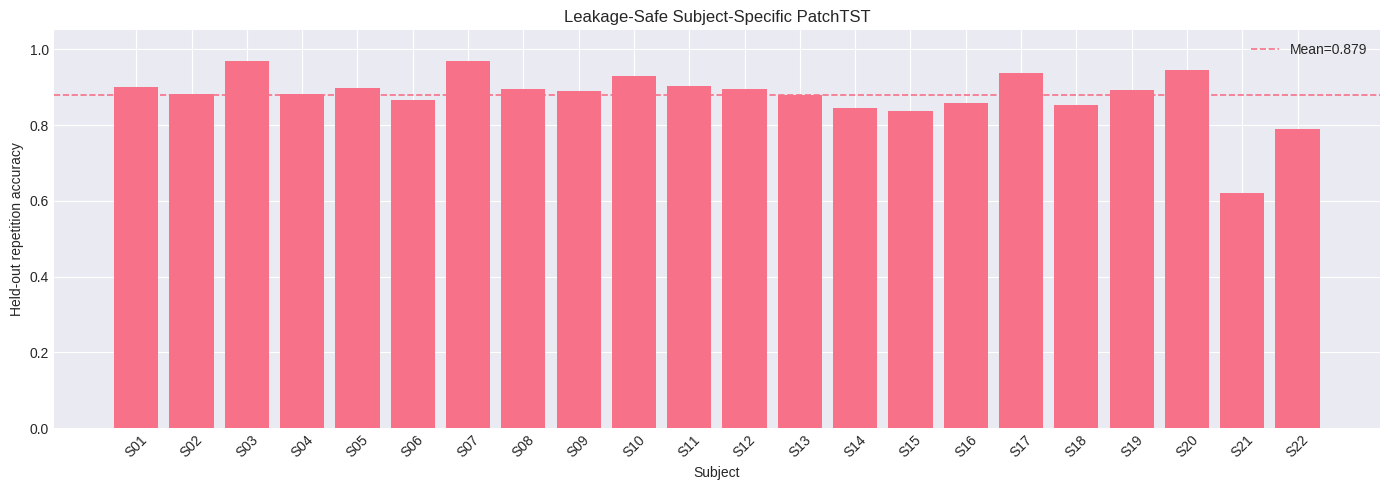

  Subject summary chart saved -> patchtst_subject_specific_accuracy_summary.png

  FINAL SUBJECT-DEPENDENT WITHIN-SUBJECT PATCHTST SUMMARY
 subject  accuracy  precision_w  recall_w     f1_w  roc_auc_w  best_epoch
       1  0.900840     0.923385  0.900840 0.898824   0.995370          31
       2  0.882952     0.905623  0.882952 0.879261   0.988459          58
       3  0.968421     0.970886  0.968421 0.968264   0.999839          17
       4  0.881081     0.901528  0.881081 0.877984   0.995535          12
       5  0.897485     0.911285  0.897485 0.896631   0.987939           6
       6  0.864865     0.898142  0.864865 0.859488   0.986948          20
       7  0.970252     0.977073  0.970252 0.968664   0.997452          22
       8  0.894841     0.874256  0.894841 0.875871   0.996265          10
       9  0.890977     0.907381  0.890977 0.886611   0.982693          34
      10  0.929134     0.932484  0.929134 0.926420   0.996793          16
      11  0.904092     0.914130  0.904092 0.902

In [15]:
def main():
    print('\n' + '=' * 70)
    print(
        '  SUBJECT-DEPENDENT WITHIN-SUBJECT PATCHTST '
        '— DISK-SAFE STRICT EMG+ACC'
    )
    print('=' * 70)
    print(
        'Each subject is loaded, split, processed, trained and evaluated '
        'independently before moving to the next subject.'
    )
    print(
        'No raw-signal cache and no overlapping-window cache are saved.'
    )

    subject_loader = SubjectLoader()

    class_names = [
        f'G{gesture}'
        for gesture in range(
            Config.GESTURE_MIN,
            Config.GESTURE_MAX + 1,
        )
    ]

    all_metrics = []
    all_y_true = []
    all_y_proba = []
    all_assignments = {}
    all_provenance = {}

    expected_n_acc_ch = None
    n_channels = None

    for sid in Config.RUN_SUBJECTS:
        print('\n' + '-' * 70)
        print(
            f'  PREPARE SUBJECT S{sid:02d}: '
            'split repetitions before all signal transforms'
        )
        print('-' * 70)

        (
            data,
            assignment,
            provenance,
            subject_n_acc_ch,
        ) = subject_loader.build_subject_splits(
            sid,
            expected_n_acc_ch=expected_n_acc_ch,
        )

        if expected_n_acc_ch is None:
            expected_n_acc_ch = int(
                subject_n_acc_ch
            )
            n_channels = (
                Config.N_EMG_CH
                + expected_n_acc_ch
            )
            print(
                f'Global input width  : {n_channels} channels '
                f'({Config.N_EMG_CH} EMG + '
                f'{expected_n_acc_ch} ACC)'
            )
        elif int(subject_n_acc_ch) != int(expected_n_acc_ch):
            raise RuntimeError(
                f'S{sid:02d}: ACC channel count changed from '
                f'{expected_n_acc_ch} to {subject_n_acc_ch}.'
            )

        all_assignments[
            str(sid)
        ] = assignment
        all_provenance[
            str(sid)
        ] = provenance

        experiment = SubjectDependentPatchTSTExperiment(
            sid=sid,
            data=data,
            n_channels=n_channels,
            n_classes=Config.N_CLASSES,
            class_names=class_names,
        )

        metrics, y_true, y_proba = (
            experiment.run()
        )

        all_metrics.append(metrics)
        all_y_true.append(y_true)
        all_y_proba.append(y_proba)

        serializable = {}
        for key, value in metrics.items():
            if isinstance(
                value,
                (np.floating, np.integer),
            ):
                serializable[key] = (
                    value.item()
                )
            else:
                serializable[key] = value

        with open(
            Config.RESULTS_DIR
            / (
                f'metrics_subject_dependent_'
                f'patchtst_S{sid:02d}.json'
            ),
            'w',
        ) as file:
            json.dump(
                serializable,
                file,
                indent=2,
            )

        # Critical disk/RAM step: discard this subject before loading the next.
        del (
            data,
            experiment,
            y_true,
            y_proba,
        )
        gc.collect()

        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_repetition_assignments.json',
        'w',
    ) as file:
        json.dump(
            all_assignments,
            file,
            indent=2,
        )

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_repetition_provenance.json',
        'w',
    ) as file:
        json.dump(
            all_provenance,
            file,
            indent=2,
        )

    subject_df, aggregate = (
        aggregate_subject_results(
            all_metrics,
            all_y_true,
            all_y_proba,
        )
    )

    subject_df.to_csv(
        Config.RESULTS_DIR
        / 'subject_dependent_within_patchtst_results.csv',
        index=False,
    )

    with open(
        Config.RESULTS_DIR
        / 'subject_dependent_within_patchtst_aggregate.json',
        'w',
    ) as file:
        json.dump(
            aggregate,
            file,
            indent=2,
        )

    plot_subject_accuracy_summary(
        subject_df
    )

    print('\n' + '=' * 70)
    print(
        '  FINAL SUBJECT-DEPENDENT '
        'WITHIN-SUBJECT PATCHTST SUMMARY'
    )
    print('=' * 70)

    print(
        subject_df[
            [
                'subject',
                'accuracy',
                'precision_w',
                'recall_w',
                'f1_w',
                'roc_auc_w',
                'best_epoch',
            ]
        ].to_string(index=False)
    )

    print(
        f'\nMean subject accuracy : '
        f'{aggregate["mean_subject_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_accuracy"]:.4f}'
    )
    print(
        f'Mean subject F1       : '
        f'{aggregate["mean_subject_f1_w"]:.4f} ± '
        f'{aggregate["std_subject_f1_w"]:.4f}'
    )
    print(
        f'Pooled test accuracy  : '
        f'{aggregate["pooled_test_accuracy"]:.4f}'
    )

    print('\nCorrect interpretation:')
    print(
        '  SUBJECT-DEPENDENT / SUBJECT-SPECIFIC: '
        'each PatchTST is trained and tested on different repetitions '
        'from the SAME person.'
    )

    print('\nLeakage controls:')
    print('  ✓ one separate PatchTST trained from scratch for each subject')
    print('  ✓ complete repetitions assigned 4/1/1 before filtering/resampling/windowing')
    print('  ✓ train/val/test repetition-ID sets explicitly disjoint')
    print('  ✓ zero-phase EMG filtering applied only inside one assigned repetition')
    print('  ✓ ACC sliced from the same source file and resampled only inside that repetition')
    print('  ✓ overlapping windows remain entirely inside one repetition/split')
    print('  ✓ no random window-level train/test split')
    print('  ✓ normalization fitted on that subject’s training repetitions only')
    print('  ✓ validation used only for epoch selection')
    print('  ✓ fresh refit normalization/model use train+validation only')
    print('  ✓ test repetition untouched until final evaluation')
    print('  ✓ patches are created inside PatchTST from each normalized raw window')
    print('  ✓ no persistent raw/window caches; one subject processed at a time')
    print('  ✓ temporary subject checkpoints deleted after evaluation')

    return (
        all_metrics,
        subject_df,
        aggregate,
        all_y_true,
        all_y_proba,
        all_assignments,
        all_provenance,
    )


if __name__ == '__main__':
    (
        all_metrics,
        per_subject_results,
        aggregate_results,
        all_y_true,
        all_y_proba,
        repetition_assignments,
        repetition_provenance,
    ) = main()